# pyGAlib example: Generation weighted (random) graphs and weighted surrogates
Authors: **Gorka Zamora-López, Ph.D.** and **Matthieu Gilson, Ph.D.**

<div align="left">
<img src="Images/Logo_CAS_ICS.png" align="left" width="254" alt="logo ICS">
</div>


<img src="Images/logo_CONECT.png" align="right" width="150" alt="logo CONECT">
<img src="Images/logo_AMU.png" align="right" width="150" alt="logo AMU">


<br>
<br>

---------------------

This notebook illustrates the options in *pyGAlib* to generate weighted graphs and weighted surrogates. In particular we will show how to:

1. Add random weights to existing graphs and digraphs (`SeedRandomWeights()`).
2. Generate (random) weighted (di)graphs.
    * `WeightedERGraph()`
    * `WeightedRandomGraph()`
4. Create surrogate weighted graphs from a given network.
    * `ErdosRenyiGraph_Like()`
    * `RandomGraph_Like()`
    * `ShuffleWeights()`

Functions to create both binary and weighted graphs can be found in module *models.py*. As usual, type `help(galib.models)` or `models?` in an interactive Python session to get a list of all network generation functions and, specific instructions for each generating function as `help(galib.FunctionName)` or `galib.FunctionName?`.


## Import dependencies

The Notebook requires a __*Python*__ (>=3.6) installation together with __*NumPy*__ (>1.6) and __*pyGAlib*__ (>=2.1), and __*Matplotlib*__ for the visualizations. Please make sure these packages are installed in the same environment in which this notebook is running.


In [1]:
# 1) Python standard library imports

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Local libraries
import galib


## 1. Seeding random weights to existing graphs and digraphs
To begin with, let's generate a small graph (e.g., a star graph) and add random weights to its links, drawn from random number distribution of choice. For that, we will use function `galib.SeedRandomWeights()`. The function accepts: 

1. Two mandatory positional parameters:
    - `adjmatrix` corresponding the (di)graph to which weights will be added, and
    - `w_dist` the random number generator function, e.g., from *NumPy* or the *SciPy* packages.
2. Various optional parameters. We will see them later.
3. Keyword arguments (`**arg_w_distr`) usually related to the random number generator `w_dist`. 

> **NOTE:** Given that *pyGAlib* is built upon *NumPy*, functions to generate binary (di)graphs return 2D *ndarrays* of `numpy.uint8` dtype. Adding random weights, or generating a new (randomly) weigthed graph returns them in `numpy.float64` dtype.

### 1.1. – Undirected graphs

Are networks directed?  net: False  |  wnet1: False  |  wnet2: False
Are weights symmetric?  net: True  |  wnet1: True  |  wnet2: True



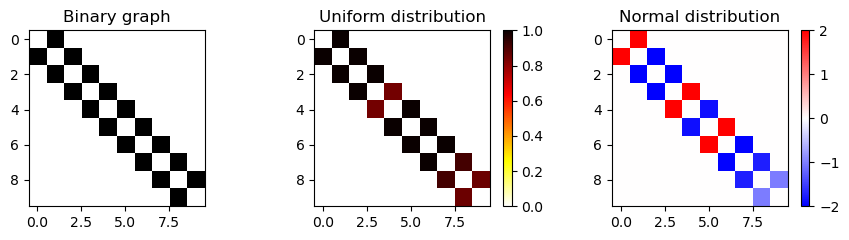

In [2]:
## GENERATE A GRAPH AND SEED RANDOM WEIGHTS TO ITS EDGES

# 1) Create a small graph
N = 10
#net = galib.StarGraph(N)
net = galib.PathGraph(N)

# 2) Create two different weigthed nets, seeding weights from 'uniform' and 'normal' distributions.

## NOTE: Specific parameters of the random number generators are passed as keyword arguments. 
## Check the documentation of each generator for a list of arguments.

# Sampling weigths from the uniform distribution, with values between 0 and 2
kwargs_uniform = {'low':0, 'high':2}
wnet1 = galib.SeedRandomWeights(net, np.random.uniform, **kwargs_uniform)

# Sampling weights from the normal distribution with mean=0 and variance=2
kwargs_normal = {'loc':0, 'scale':2}
wnet2 = galib.SeedRandomWeights(net, np.random.normal,  **kwargs_normal)



#######################################################################################
## FEEDBACK, NO NEED TO EDIT FROM HERE ################################################

# Print some feedback ...
print( f"Are networks directed?  net: {galib.is_directed(net)}  |  wnet1: {galib.is_directed(wnet1)}  |  wnet2: {galib.is_directed(wnet2)}" )
print( f"Are weights symmetric?  net: {galib.is_symmetric(net)}  |  wnet1: {galib.is_symmetric(wnet1)}  |  wnet2: {galib.is_symmetric(wnet2)}" )
print()


# Visualize the generated matrices
plt.figure(figsize=(9,2.5))

plt.subplot(1,3,1)
plt.title( 'Binary graph' )
plt.imshow(net, cmap='gray_r')

plt.subplot(1,3,2)
plt.title( 'Uniform distribution' )
plt.imshow(wnet1, cmap='hot_r')
plt.clim(0,1)
plt.colorbar()

plt.subplot(1,3,3)
plt.title( 'Normal distribution' )
plt.imshow(wnet2, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As seen, symmetric weights were seeded such that $w_{ij} = w_{ji}$. This is because `SeedRandomWeights()` identifies whether the input adjacency matrix $A$ represents a directed or an undirected graph, and behaves accordingly. But this behaviour can be altered using optional parameter `sym_w`. 


In the **default behaviour** (`sym_w = None`) the function first checks the directedness of the input matrix and then seeds the random weights accordingly:

- If $A$ represents an ***undirected graph***, then weights are symmetrically seeded such that $w_{ji} = w_{ij}$.
- If $A$ represents a ***directed graph***, then each link $i \to j$ receives an independent weight $w_{ij}$.

<br>

However, setting `sym_w = False` forces `SeedRandomWeights()`to treat every entry $A_{ij} = 1$ independently and assign its own weight $w_{ij}$, regardless of whether $A$ is directed or undirected. As a consequence, the resulting network is always asymmetric, with $w_{ij} \neq w_{ji}$. We show this in the example below, where we repeat the previous cell but setting optional parameter `sym_w = False` to generate asymmetric graphs.

Are networks directed?  net: False  |  wnet1: False  |  wnet2: False
Are weights symmetric?  net: True  |  wnet1: False  |  wnet2: False



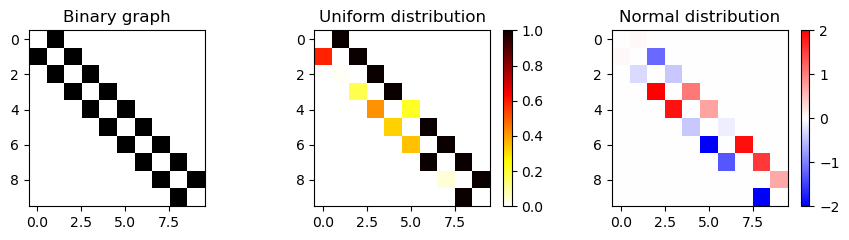

In [3]:
## ASSIGN ASYMMETRIC RANDOM WEIGHTS TO AN UNDIRECTED GRAPH
# Same as before, but setting optional parameter sym_w = False

wnet1 = galib.SeedRandomWeights(net, np.random.uniform, sym_w=False,  low=0, high=2)
wnet2 = galib.SeedRandomWeights(net, np.random.normal,  sym_w=False,  loc=0, scale=2)

## NOTE: For simplicity, we passed the keyword arguments of the distributions directly 
## at the end of the list of parameters. Just a cosmetic change.


#######################################################################################
## FEEDBACK, NO NEED TO EDIT FROM HERE ################################################

# Print some feedback ...
print( f"Are networks directed?  net: {galib.is_directed(net)}  |  wnet1: {galib.is_directed(wnet1)}  |  wnet2: {galib.is_directed(wnet2)}" )
print( f"Are weights symmetric?  net: {galib.is_symmetric(net)}  |  wnet1: {galib.is_symmetric(wnet1)}  |  wnet2: {galib.is_symmetric(wnet2)}" )
print()


# Visualize the generated matrices
plt.figure(figsize=(9,2.5))

plt.subplot(1,3,1)
plt.title( 'Binary graph' )
plt.imshow(net, cmap='gray_r')

plt.subplot(1,3,2)
plt.title( 'Uniform distribution' )
plt.imshow(wnet1, cmap='hot_r')
plt.clim(0,1)
plt.colorbar()

plt.subplot(1,3,3)
plt.title( 'Normal distribution' )
plt.imshow(wnet2, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As expected, the two weighted networks are still undirected, like the binary graph, but their link weights are no longer symmetric.

<br>

On the other hand, seting `sym_w = True` the function will return a weighted matrix as symmetric as possible. To do so, `SeedRandomWeights()` will treat reciprocal ($ i \leftrightarrow j$) and purely directed ($i \to j$) links differently; seeding symmetric weights ($w_{ji} = w_{ij}$) for reciprocal links and independent weights ($w_{ij}$) for directed ones. Therefore, 

- if $A$ represents an ***undirected graph***, the result is a symmetric weighted matrix (the default behaviour), but
- if $A$ is a ***directed graph***, then its reciprocal links (if any) will be given symmetric weights, while the purely directed links will each obtain an independent weight.



### 1.2. – Directed graphs

In the following we show two examples for the default (`sym_w = None`) and the symmetric (`sym_w = True`) modes on digraphs. For completeness, we will not only visually the resulting weighted adjacency matrix, but we will include the results for the reciprocal and directed components of the networks. Meaning, we will show separately the subset of the digraph made of reciprocal edges (where $A_{ij} = A_{ji} = 1$), and subset made of purely directed arcs (say, $A_{ij} = 1$ but $A_{ji} = 0$).

We begin by generating a digraph with weights seeded completely randomly (default case, when `sym_w = None`).

Are networks directed?  net: True  |  wnet: True  |  undir. component: False  |  dir. component: True
Are weights symmetric?  net: False  |  wnet: False  |  undir. component: False  |  directed component: False



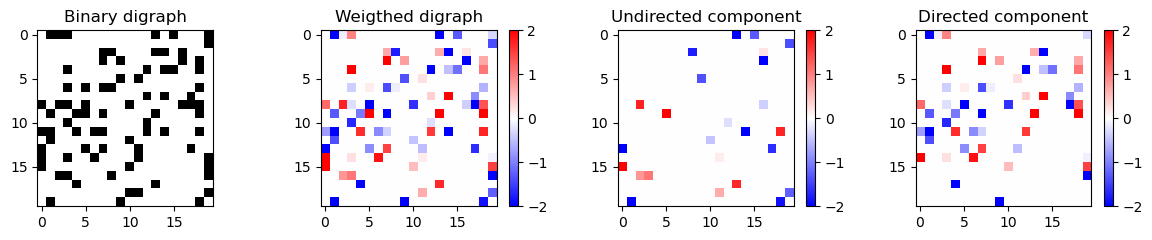

In [4]:
## GENERATE A DIRECTED GRAPH AND SEED RANDOM WEIGHTS TO ITS LINKS (ARCS)

# 1) We create a small random digraph
N = 20
linkprob = 0.2
dirnet = galib.ErdosRenyiGraph(N,linkprob, directed=True)

# 2) Assign random weights from a normal distribution of mean=0 and variance=2
wdirnet = galib.SeedRandomWeights(dirnet, np.random.normal, loc=0,scale=2)



#######################################################################################
## FEEDBACK, NO NEED TO EDIT FROM HERE ################################################

# Define the masks for the reciprocal and the directed components
mask = dirnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wnet_und = wdirnet * mask_und
wnet_dir = wdirnet * mask_dir

# Print some feedback ...
print( f"Are networks directed?  net: {galib.is_directed(dirnet)}  |  wnet: {galib.is_directed(wdirnet)}  |  \
undir. component: {galib.is_directed(wnet_und)}  |  dir. component: {galib.is_directed(wnet_dir)}" )
print( f"Are weights symmetric?  net: {galib.is_symmetric(dirnet)}  |  wnet: {galib.is_symmetric(wdirnet)}  |  \
undir. component: {galib.is_symmetric(wnet_und)}  |  directed component: {galib.is_symmetric(wnet_dir)}" )
print()


# Visualize all the matrices: digraph, weighted and the two components
plt.figure(figsize=(12,2.5))

plt.subplot(1,4,1)
plt.title( 'Binary digraph' )
plt.imshow(dirnet, cmap='gray_r')

plt.subplot(1,4,2)
plt.title( 'Weigthed digraph' )
plt.imshow(wdirnet, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,3)
plt.title( 'Undirected component' )
plt.imshow(wnet_und, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,4)
plt.title( 'Directed component' )
plt.imshow(wnet_dir, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As seen, in this default behaviour (`sym_w = None`) the function identified that the input matrix represents a directed graph and therefore sets to seed weights at random, considering every directed link (entry with $A_{ij} = 1$) independently. Even if the digraph contains a few reciprocal links ($A_{ij} = A_{ji} = 1$) shown in the undirected component, their weights are not symmetric. Notice that this is the same behaviour that would result if we had set `sym_w = False` but, in the default case, `SeedRandomWeights()` identifies which behaviour to use depending on whether the input adjacency matrix is directed or undirected.

<br>

Finally, when setting `sym_w = True` the function `SeedRandomGraphs()` will seed symmetric weights for all reciprocal links that it finds. As we show now in the following example.

Are networks directed?  net: True  |  wnet: True  |  undir. component: False  |  dir. component: True
Are weights symmetric?  net: False  |  wnet: False  |  undir. component: True  |  directed component: False



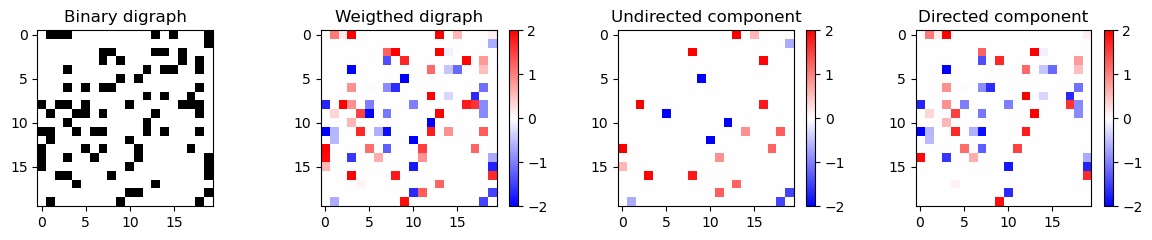

In [5]:
## GENERATE A DIRECTED GRAPH AND SEED WEIGHTS AS SYMMETRIC AS POSSIBLE

# # 1) We use the same digraph as above, or generate a new one uncommenting
# N = 20
# linkprob = 0.2
# dirnet = galib.ErdosRenyiGraph(N,linkprob, directed=True)

# 2) Assign random weights from a normal distribution of mean=0 and variance=2
# This time, set optional parameter `sym_w = True`
wdirnet = galib.SeedRandomWeights(dirnet, np.random.normal, sym_w=True, loc=0,scale=2)



#######################################################################################
## FEEDBACK, NO NEED TO EDIT FROM HERE ################################################

# Define the masks for the reciprocal and the directed components
mask = dirnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wnet_und = wdirnet * mask_und
wnet_dir = wdirnet * mask_dir

# Print some feedback ...
print( f"Are networks directed?  net: {galib.is_directed(dirnet)}  |  wnet: {galib.is_directed(wdirnet)}  |  \
undir. component: {galib.is_directed(wnet_und)}  |  dir. component: {galib.is_directed(wnet_dir)}" )
print( f"Are weights symmetric?  net: {galib.is_symmetric(dirnet)}  |  wnet: {galib.is_symmetric(wdirnet)}  |  \
undir. component: {galib.is_symmetric(wnet_und)}  |  directed component: {galib.is_symmetric(wnet_dir)}" )
print()


# Visualize all the matrices: digraph, weighted and the two components
plt.figure(figsize=(12,2.5))

plt.subplot(1,4,1)
plt.title( 'Binary digraph' )
plt.imshow(dirnet, cmap='gray_r')

plt.subplot(1,4,2)
plt.title( 'Weigthed digraph' )
plt.imshow(wdirnet, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,3)
plt.title( 'Undirected component' )
plt.imshow(wnet_und, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,4)
plt.title( 'Directed component' )
plt.imshow(wnet_dir, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()

This time, with `sym_w = True` set, `SeedRandomWeights()` managed to give symmetric weights to the reciprocal edges (undirected component) while the rest of links, each receives an independent weight, as seen in the matrix for the directed component.

## 2. Generating weighted random (di)graphs (from scratch)

As shown in the previous section, the function `SeedRandomWeights()` returns a copy of an input `adjmatrix` with random weights added to it. Therefore, weighted (random) graphs can be easily generated by creating a binary random graph first, and adding weights to it. For example, this is how we would add random uniform weights to a scale-free graph (following the rich-gets-richer method in Barabási & Albert, 2000) of $N = 10000$ nodes, and $m = 5$ links per new node:
```python
>>> wrnet = BarabasiAlbertGraph(10000, 5)
>>> wrnet = SeedRandomWeights(wrnet, numpy.random.uniform, low=0, high=1)
```

> **NOTE:** `SeedRandomWeights()` always returns a new array, instead of seeding the weights in-place to the input matrix. In the examples of Section 1 we created independent weighted versions from a binary graph. Here, we created a binary graph `wrnet` in the first line and overrode it in the second line, by calling `wrnet = SeedRandomWeights(wrnet, ...)` To do so, *NumPy* still needs to create two matrices and keep them in memory, although the first (binary) one is cleaned-up at the end of the process. This behaviour allows more flexibility than if the function would always seed the weights "in-place" to the input matrix.



While this simple procedure would work for any (random) graph we may generate in the first step, the canonical model for random graphs comes in two flavours: the $G(N,p)$ for graphs of $N$ nodes and link probability $p$, and the $G(N,L)$ model for random graphs of size $N$ and fixed number of links $L$. Given the relevance of two models and their common use, pyGAlib provides a few shortcuts to generate weighted versions of them. To generate them "from scratch", the following functions are "syntactic sugar" merging the two-call step into into one:

* `galib.models.WeightedERGraph()` 
* `galib.models.WeightedRandomGraph()` 

They inherit the parameters from both the `ErdosRenyiGraph()` (the `RandomGraph()`) function and the `SeedRandomWeights()`. Thus, they accept …

* Three mandatory positional parameters:
    - `N`: number of nodes.
    - `p`: link probability (`L`: number of links).
    - `w_dist` the random number generator function, e.g., from *NumPy* or the *SciPy* packages.
* Various optional parameters.
    - `directed`: whether a digraph or a graph is desired.
    - `selfloops`: if generation of self-loops (diagonal entries) is allowed.
    - `sym_w`: whether reciprocal edges will be given the same weight.
* Keyword arguments `**arg_w_distr` usually related to the random number generator `w_dist`. 

As an example, the following cell generates an Erdos-Renyi graph with random weights assigned from the normal distribution. The user will notice that this almost the same as the last example in Section 1.2, but with the output generated in a single function call.

Are the networks directed in ...  wrnet: True  |  undirected component: False  |  directed component: True
Are the weights symmetric in ...  wrnet: False |  undirected component: True  |  directed component: False



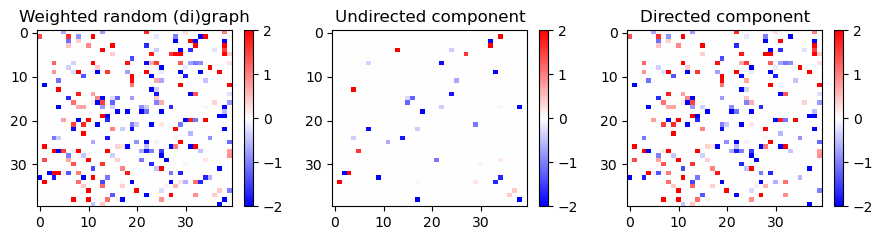

In [6]:
## GENERATE AN ERDOS-RENYI RANDOM (DI)GRAPH WITH WEIGHTS SAMPLED FROM A NORMAL DISTRIBUTION

# 1) Define the main parameters
# Positional arguments
N = 40
p = 0.15   # Between 0 and 1
w_distr = numpy.random.normal   # e.g., numpy.random.uniform

# Optional arguments
_directed = True   # True, False
_selfloops = True  # True, False
_sym_w = True      # None, True, False

# Keyword arguments (depend on the distribution chosen)
_kwargs = {'loc':0, 'scale':2}


# 2) Generate the random and weighted (di)graph
wrnet = galib.models.WeightedERGraph(N, p, w_distr, 
                                     directed = _directed, 
                                     selfloops = _selfloops, 
                                     sym_w = _sym_w,
                                     **_kwargs)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Visualise the generated (di)graph and check the (un)directed components
# Define the masks for the reciprocal and the directed components
mask = wrnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wrnet_und = wrnet * mask_und
wrnet_dir = wrnet * mask_dir

# Print some feedback ...
print( f"Are the networks directed in ...  wrnet: {galib.is_directed(wrnet)}  |  \
undirected component: {galib.is_directed(wrnet_und)}  |  directed component: {galib.is_directed(wrnet_dir)}" )
print( f"Are the weights symmetric in ...  wrnet: {galib.is_symmetric(wrnet)} |  \
undirected component: {galib.is_symmetric(wrnet_und)}  |  directed component: {galib.is_symmetric(wrnet_dir)}" )
print()


# Visualize the weighted adjacency matrix and the two components separately
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.title( 'Weighted random (di)graph' )
plt.imshow(wrnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,2)
plt.title( 'Undirected component' )
plt.imshow(wrnet_und, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,3)
plt.title( 'Directed component' )
plt.imshow(wrnet_dir, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


## 3. Generation of weighted surrogates from empirical networks

Given an empirical or synthetic network $A$, a surrogate of $A$ is another network that conserves some of the constraints of $A$ but other properties are randomised. There are different manners to construct surrogate networks, depending on which properties are conserved and which are randomised. The choice depends on the questions we want to ask about $A$ and, thus, there are no "right" or "wrong" surrogate models, as long as their creation satisfies the assumptions and correctly conserve (randomise) the desired properties.

Here, we will show three types of surrogates that can be generated for weighted networks using *pyGAlib*:

1. Equivalent random (di)graphs with random weights
    - `ErdosRenyiGraph_Like()`
    - `RandomGraph_Like()`
2. Shuffle the link weights, while conserving the underlying structure
    - `ShuffleWeights()`
3. Randomise links and weights by link rewiring
    - `RewireNetwork()`



CONTINUE HERE !!

### 3.1 - Weighted random (di)graphs from empirical networks

Section 2 explained how to generate random weighted (di)graphs from scratch, using `WeightedERGraph()` and `WeightedRandomGraph()`. These functions take the basic constraints (*N*, *L*, or *p*). Given an empirical or synthenic network *A*, in order to generate equivalent random graphs we would need to first compute those parameters and then pass them into the functions. *pyGAlib* includes two functions to make this even simpler: `

* `ErdosRenyiGraph_Like()`and
* `RandomGraph_Like()`.

These two functions accept the same set of parameters:

1. One mandatory positional parameter:
    - `adjamatrix` : the adjacency matrix of a given network, either binary or weighted.
2. Two optional parameters:
    - `w_distr` :  the random number generator function, e.g., from NumPy or the SciPy packages.
    - `sym_w` : control parameter to enforce symmetric or asymmetric weights.
3. And, keyword arguments (`**arg_w_distr`) related to the random number generator `w_dist`.

Calling them will first automatically identify the core (binary) constraints of the input `adjmatrix` (i.e., its size, density, number of links, directedness, symmetry, etc.) and will then generate an equivalent random graph with the same parameters. Note that, contrary to the pervious functions described in Sections 1 and 2, here `w_distr` is an optional parameter. By default `w_distr = None`, meaning that the functions will return binary random graphs of the same characteristic as `ErdosRenyiGraph()` and `RandomGraph()` would do. As shown in the next example where:

1. We Load an empirical network (*realnet*). This can be either directed or undirected, binary or weighted.
2. We first generate an equivalent random (di)graph of same size, directedness and number of links.
3. And then we generate an equivalent random (di)graph with random link weights.



Is the network directed?  Empirical: False  |  random: False 
Number of nodes N ...	Empirical: 77  |  random: 77 
Density of the net ...	Empirical: 0.0868  |  random: 0.0868 
Number of links L ...	Empirical: 508  |  random: 508 
Number self-loops ...	Empirical: 0  |  random: 0 



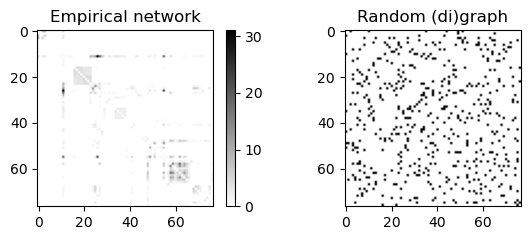

In [7]:
## GENERATING A RANDOM BINARY GRAPH, FROM AN EMPIRICAL NETWORK
# 1) Load an empirical network (CHOOSE ONE)
dataroot = "./Data/"
# realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
# realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
# realnet = galib.tools.LoadFromPajek(dataroot + 'Dolphins.net', getlabels=False)
realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)

# 2) Generate an equivalent binary random graph (CHOOSE ONE)
# rnet = galib.models.ErdosRenyiGraph_Like(realnet)
rnet = galib.models.RandomGraph_Like(realnet)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Compare their main characteristics
dir_real = galib.is_directed(realnet)
dir_rand = galib.is_directed(rnet)
print( f'Is the network directed?  Empirical: {dir_real}  |  random: {dir_rand} ' )

Nreal = len(realnet); Nrand = len(rnet)
print( f'Number of nodes N ...\tEmpirical: {Nreal:d}  |  random: {Nrand:d} ' )

dens_real = galib.Density(realnet)
dens_rand = galib.Density(rnet)
print( f'Density of the net ...\tEmpirical: {dens_real:1.4f}  |  random: {dens_rand:1.4f} ' )

Lreal = realnet.astype(bool).sum()
Lrand = rnet.sum()
print( f'Number of links L ...\tEmpirical: {Lreal:d}  |  random: {Lrand:d} ' )

Lreal_diag = realnet.astype(bool).trace()
Lrand_diag = rnet.trace()
print( f'Number self-loops ...\tEmpirical: {Lreal_diag:d}  |  random: {Lrand_diag:d} ' )
print()


# 3) Plot the two adjacency matrices
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.title( 'Empirical network' )
plt.imshow(realnet, cmap='gray_r')
plt.colorbar()

plt.subplot(1,3,2)
plt.title( 'Random (di)graph' )
plt.imshow(rnet, cmap='gray_r')

plt.tight_layout()

#

##### Generate a weighted random graph

Is the network directed?  Empirical: False  |  random: False 
Number of nodes N ...	Empirical: 34  |  random: 34 
Density of the net ...	Empirical: 0.1390  |  random: 0.1390 
Number of links L ...	Empirical: 156  |  random: 156 
Number self-loops ...	Empirical: 0  |  random: 0 



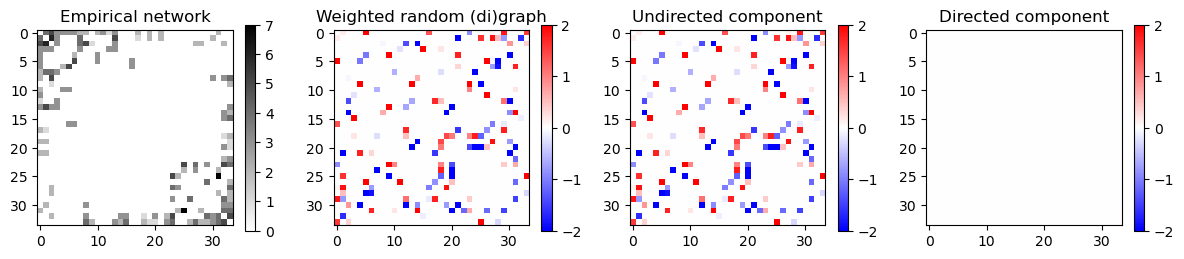

In [8]:
## GENERATING A RANDOM GRAPH OF G(N,L) TYPE WITH RANDOM WEIGHTS, FROM AN EMPIRICAL NETWORK

# 1) Load an empirical network (CHOOSE ONE)
dataroot = "./Data/"
# realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
# realnet = galib.tools.LoadFromPajek(dataroot + 'Dolphins.net', getlabels=False)
# realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)


# 2) Generate an equivalent random graph with random weights
# Edit the parameters regarding the weight distribution
_sym_w = None      # None, True, False

_w_distr = numpy.random.normal   # e.g., numpy.random.uniform
_kwargs = {'loc':0, 'scale':2}

# Generate the matrix
wrnet = galib.models.RandomGraph_Like(realnet, sym_w=_sym_w, w_distr=_w_distr, **_kwargs)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Compare their main characteristics
dir_real = galib.is_directed(realnet)
dir_rand = galib.is_directed(wrnet)
print( f'Is the network directed?  Empirical: {dir_real}  |  random: {dir_rand} ' )

Nreal = len(realnet); Nrand = len(wrnet)
print( f'Number of nodes N ...\tEmpirical: {Nreal:d}  |  random: {Nrand:d} ' )

dens_real = galib.Density(realnet)
dens_rand = galib.Density(wrnet)
print( f'Density of the net ...\tEmpirical: {dens_real:1.4f}  |  random: {dens_rand:1.4f} ' )

Lreal = realnet.astype(bool).sum()
Lrand = wrnet.astype(bool).sum()
print( f'Number of links L ...\tEmpirical: {Lreal:d}  |  random: {Lrand:d} ' )

Lreal_diag = realnet.astype(bool).trace()
Lrand_diag = rnet.astype(bool).trace()
print( f'Number self-loops ...\tEmpirical: {Lreal_diag:d}  |  random: {Lrand_diag:d} ' )
print()


# 4) Plot the adjacency matrices
# Define the masks for the reciprocal and the directed components
mask = wrnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wrnet_und = wrnet * mask_und
wrnet_dir = wrnet * mask_dir

# Plot the figure
plt.figure(figsize=(12,2.5))

plt.subplot(1,4,1)
plt.title( 'Empirical network' )
plt.imshow(realnet, cmap='gray_r')
plt.colorbar()

plt.subplot(1,4,2)
plt.title( 'Weighted random (di)graph' )
plt.imshow(wrnet, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,3)
plt.title( 'Undirected component' )
plt.imshow(wrnet_und, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,4)
plt.title( 'Directed component' )
plt.imshow(wrnet_dir, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


> **Note that**, if `ErdosRenyi_Like()` and `RandomGraph_Like()` are called to return a binary (digraph), they return a matrix of `np.uint8` ndtype. If weights are seeded, then a matrix of `np.float64` ndtype is returned.